In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np


In [1]:
## global configuration


### Block Level Effectiveness

In [2]:
block_level_data = [
    {
        "Project": "flameshot",
        "Method": "MergeBot",
        "Correct": 14,
        "Smaller": 3,
        "Incorrect": 2,
        "Unchanged": 7,
        "TokenLimited": 0,
    },
    {
        "Project": "flameshot",
        "Method": "MergeGen",
        "Correct": 7,
        "Smaller": 0,
        "Incorrect": 17,
        "Unchanged": 0,
        "TokenLimited": 2,
    },


    {
        "Project": "duckdb",
        "Method": "MergeBot",
        "Correct": 47,
        "Smaller": 22,
        "Incorrect": 14,
        "Unchanged": 60,
        "TokenLimited": 0,
    },
    {
        "Project": "duckdb",
        "Method": "MergeGen",
        "Correct": 80,
        "Smaller": 0,
        "Incorrect": 62,
        "Unchanged": 0,
        "TokenLimited": 1,
    },


    {
        "Project": "rocksdb",
        "Method": "MergeBot",
        "Correct": 118,
        "Smaller": 10,
        "Incorrect": 75,
        "Unchanged": 42,
        "TokenLimited": 0,
    },
    {
        "Project": "rocksdb",
        "Method": "MergeGen",
        "Correct": 68,
        "Smaller": 0,
        "Incorrect": 156,
        "Unchanged": 0,
        "TokenLimited": 21,
    },


    {
        "Project": "grpc",
        "Method": "MergeBot",
        "Correct": 42,
        "Smaller": 18,
        "Incorrect": 48,
        "Unchanged": 44,
        "TokenLimited": 0,
    },
    {
        "Project": "grpc",
        "Method": "MergeGen",
        "Correct": 66,
        "Smaller": 0,
        "Incorrect": 83,
        "Unchanged": 0,
        "TokenLimited": 3,
    },


    {
        "Project": "art",
        "Method": "MergeBot",
        "Correct": 43,
        "Smaller": 9,
        "Incorrect": 15,
        "Unchanged": 61,
        "TokenLimited": 0,
    },
    {
        "Project": "art",
        "Method": "MergeGen",
        "Correct": 71,
        "Smaller": 0,
        "Incorrect": 49,
        "Unchanged": 0,
        "TokenLimited": 8,
    },


    {
        "Project": "frameworks/av",
        "Method": "MergeBot",
        "Correct": 103,
        "Smaller": 40,
        "Incorrect": 18,
        "Unchanged": 103,
        "TokenLimited": 0,
    },
    {
        "Project": "frameworks/av",
        "Method": "MergeGen",
        "Correct": 173,
        "Smaller": 0,
        "Incorrect": 72,
        "Unchanged": 0,
        "TokenLimited": 19,
    },


    {
        "Project": "frameworks/native",
        "Method": "MergeBot",
        "Correct": 121,
        "Smaller": 24,
        "Incorrect": 10,
        "Unchanged": 24,
        "TokenLimited": 0,
    },
    {
        "Project": "frameworks/native",
        "Method": "MergeGen",
        "Correct": 153,
        "Smaller": 0,
        "Incorrect": 23,
        "Unchanged": 0,
        "TokenLimited": 3,
    },


    {
        "Project": "system/core",
        "Method": "MergeBot",
        "Correct": 83,
        "Smaller": 15,
        "Incorrect": 19,
        "Unchanged": 43,
        "TokenLimited": 0,
    },
    {
        "Project": "system/core",
        "Method": "MergeGen",
        "Correct": 62,
        "Smaller": 0,
        "Incorrect": 71,
        "Unchanged": 0,
        "TokenLimited": 27,
    },


    {
        "Project": "redis",
        "Method": "MergeBot",
        "Correct": 19,
        "Smaller": 2,
        "Incorrect": 7,
        "Unchanged": 40,
        "TokenLimited": 0,
    },
    {
        "Project": "redis",
        "Method": "MergeGen",
        "Correct": 28,
        "Smaller": 0,
        "Incorrect": 32,
        "Unchanged": 0,
        "TokenLimited": 8,
    },


    {
        "Project": "tmux",
        "Method": "MergeBot",
        "Correct": 39,
        "Smaller": 8,
        "Incorrect": 22,
        "Unchanged": 24,
        "TokenLimited": 0,
    },
    {
        "Project": "tmux",
        "Method": "MergeGen",
        "Correct": 21,
        "Smaller": 0,
        "Incorrect": 59,
        "Unchanged": 0,
        "TokenLimited": 13,
    },
]

In [3]:
df_block = pd.DataFrame(block_level_data)
print("初始数据：")

df_block.head(20)

NameError: name 'pd' is not defined

#### 验证每个方法在每个项目上的总和是一致的

In [ ]:
category_columns = ["Correct", "Smaller", "Incorrect", "Unchanged", "TokenLimited"]
df_block['Total'] = df_block[category_columns].sum(axis=1)
df_block.head(20)

,Project,Method,Correct,Smaller,Incorrect,Unchanged,TokenLimited,Total
0,flameshot,MergeBot,14,3,2,7,0,26
1,flameshot,MergeGen,7,0,17,0,2,26
2,duckdb,MergeBot,47,22,14,60,0,143
3,duckdb,MergeGen,80,0,62,0,1,143
4,rocksdb,MergeBot,118,10,75,42,0,245
5,rocksdb,MergeGen,68,0,156,0,21,245
6,grpc,MergeBot,42,18,48,44,0,152
7,grpc,MergeGen,66,0,83,0,3,152
8,art,MergeBot,43,9,15,61,0,128
9,art,MergeGen,71,0,49,0,8,128


In [ ]:
# 判断逐项目，逐方法的总和是否相等
grouped = df_block.groupby(['Project', 'Method'])['Total'].sum().unstack()

# 验证 MergeBot 和 MergeGen 的总计是否相等
grouped['Totals_Equal'] = grouped['MergeBot'] == grouped['MergeGen']

grouped

Method,MergeBot,MergeGen,Totals_Equal
Project,,,
art,128,128,True
duckdb,143,143,True
flameshot,26,26,True
frameworks/av,264,264,True
frameworks/native,179,179,True
grpc,152,152,True
redis,68,68,True
rocksdb,245,245,True
system/core,160,160,True


In [ ]:
# 创建新的 DataFrame 存储验证结果
validation_df = grouped[['MergeBot', 'MergeGen', 'Totals_Equal']].reset_index()

# 重命名列
validation_df.rename(columns={
    'MergeBot': 'MergeBot_Total',
    'MergeGen': 'MergeGen_Total',
    'Totals_Equal': 'Is_Total_Equal'
}, inplace=True)

# 显示验证结果
print("验证结果 DataFrame:")
validation_df

验证结果 DataFrame:


Method,Project,MergeBot_Total,MergeGen_Total,Is_Total_Equal
0,art,128,128,True
1,duckdb,143,143,True
2,flameshot,26,26,True
3,frameworks/av,264,264,True
4,frameworks/native,179,179,True
5,grpc,152,152,True
6,redis,68,68,True
7,rocksdb,245,245,True
8,system/core,160,160,True
9,tmux,93,93,True


#### 计算Precision和Recall

In [ ]:
def calculate_metrics(row):
    if row['Method'] == 'MergeBot':
        precision_denominator = row['Correct'] + row['Smaller'] + row['Incorrect']
        precision = row['Correct'] / precision_denominator if precision_denominator != 0 else 0
    elif row['Method'] == 'MergeGen':
        precision = row['Correct'] / row['Total'] if row['Total'] != 0 else 0
    else:
        precision = None  # 如果有其他方法，可以根据需要调整
    
    accuracy = row['Correct'] / row['Total'] if row['Total'] != 0 else 0
    
    return pd.Series({'Precision': precision, 'Accuracy': accuracy})

df_block[['Precision', 'Accuracy']] = df_block.apply(calculate_metrics, axis=1)
df_block.head(20)


,Project,Method,Correct,Smaller,Incorrect,Unchanged,TokenLimited,Total,Precision,Accuracy
0,flameshot,MergeBot,14,3,2,7,0,26,0.736842,0.538462
1,flameshot,MergeGen,7,0,17,0,2,26,0.269231,0.269231
2,duckdb,MergeBot,47,22,14,60,0,143,0.566265,0.328671
3,duckdb,MergeGen,80,0,62,0,1,143,0.559441,0.559441
4,rocksdb,MergeBot,118,10,75,42,0,245,0.581281,0.481633
5,rocksdb,MergeGen,68,0,156,0,21,245,0.277551,0.277551
6,grpc,MergeBot,42,18,48,44,0,152,0.388889,0.276316
7,grpc,MergeGen,66,0,83,0,3,152,0.434211,0.434211
8,art,MergeBot,43,9,15,61,0,128,0.641791,0.335938
9,art,MergeGen,71,0,49,0,8,128,0.554688,0.554688


In [ ]:
# 选择需要的列
metrics_df = df_block[['Project', 'Method', 'Precision', 'Accuracy']]

# 计算每种方法的平均 Precision 和 Accuracy
average_metrics = metrics_df.groupby("Method")[["Precision", "Accuracy"]].mean().reset_index()

average_metrics

,Method,Precision,Accuracy
0,MergeBot,0.628866,0.424466
1,MergeGen,0.463024,0.463024


In [ ]:
block_level_data = [
    {
        "Project": "flameshot",
        "Method": "MergeBot",
        "Correct": 14,
        "Smaller": 3,
        "Incorrect": 2,
        "Unchanged": 7,
        "TokenLimited": 0,
    },
    {
        "Project": "flameshot",
        "Method": "MergeGen",
        "Correct": 7,
        "Smaller": 0,
        "Incorrect": 17,
        "Unchanged": 0,
        "TokenLimited": 2,
    },


    {
        "Project": "duckdb",
        "Method": "MergeBot",
        "Correct": 47,
        "Smaller": 22,
        "Incorrect": 14,
        "Unchanged": 60,
        "TokenLimited": 0,
    },
    {
        "Project": "duckdb",
        "Method": "MergeGen",
        "Correct": 80,
        "Smaller": 0,
        "Incorrect": 62,
        "Unchanged": 0,
        "TokenLimited": 1,
    },


    {
        "Project": "rocksdb",
        "Method": "MergeBot",
        "Correct": 118,
        "Smaller": 10,
        "Incorrect": 75,
        "Unchanged": 42,
        "TokenLimited": 0,
    },
    {
        "Project": "rocksdb",
        "Method": "MergeGen",
        "Correct": 68,
        "Smaller": 0,
        "Incorrect": 156,
        "Unchanged": 0,
        "TokenLimited": 21,
    },


    {
        "Project": "grpc",
        "Method": "MergeBot",
        "Correct": 42,
        "Smaller": 18,
        "Incorrect": 48,
        "Unchanged": 44,
        "TokenLimited": 0,
    },
    {
        "Project": "grpc",
        "Method": "MergeGen",
        "Correct": 66,
        "Smaller": 0,
        "Incorrect": 83,
        "Unchanged": 0,
        "TokenLimited": 3,
    },


    {
        "Project": "art",
        "Method": "MergeBot",
        "Correct": 43,
        "Smaller": 9,
        "Incorrect": 15,
        "Unchanged": 61,
        "TokenLimited": 0,
    },
    {
        "Project": "art",
        "Method": "MergeGen",
        "Correct": 71,
        "Smaller": 0,
        "Incorrect": 49,
        "Unchanged": 0,
        "TokenLimited": 8,
    },


    {
        "Project": "frameworks/av",
        "Method": "MergeBot",
        "Correct": 103,
        "Smaller": 40,
        "Incorrect": 18,
        "Unchanged": 103,
        "TokenLimited": 0,
    },
    {
        "Project": "frameworks/av",
        "Method": "MergeGen",
        "Correct": 173,
        "Smaller": 0,
        "Incorrect": 72,
        "Unchanged": 0,
        "TokenLimited": 19,
    },


    {
        "Project": "frameworks/native",
        "Method": "MergeBot",
        "Correct": 121,
        "Smaller": 24,
        "Incorrect": 10,
        "Unchanged": 24,
        "TokenLimited": 0,
    },
    {
        "Project": "frameworks/native",
        "Method": "MergeGen",
        "Correct": 153,
        "Smaller": 0,
        "Incorrect": 23,
        "Unchanged": 0,
        "TokenLimited": 3,
    },


    {
        "Project": "system/core",
        "Method": "MergeBot",
        "Correct": 83,
        "Smaller": 15,
        "Incorrect": 19,
        "Unchanged": 43,
        "TokenLimited": 0,
    },
    {
        "Project": "system/core",
        "Method": "MergeGen",
        "Correct": 62,
        "Smaller": 0,
        "Incorrect": 71,
        "Unchanged": 0,
        "TokenLimited": 27,
    },


    {
        "Project": "redis",
        "Method": "MergeBot",
        "Correct": 19,
        "Smaller": 2,
        "Incorrect": 7,
        "Unchanged": 40,
        "TokenLimited": 0,
    },
    {
        "Project": "redis",
        "Method": "MergeGen",
        "Correct": 28,
        "Smaller": 0,
        "Incorrect": 32,
        "Unchanged": 0,
        "TokenLimited": 8,
    },


    {
        "Project": "tmux",
        "Method": "MergeBot",
        "Correct": 39,
        "Smaller": 8,
        "Incorrect": 22,
        "Unchanged": 24,
        "TokenLimited": 0,
    },
    {
        "Project": "tmux",
        "Method": "MergeGen",
        "Correct": 21,
        "Smaller": 0,
        "Incorrect": 59,
        "Unchanged": 0,
        "TokenLimited": 13,
    },
]

In [ ]:
df_block = pd.DataFrame(block_level_data)
print("初始数据：")

df_block.head(20)

初始数据：


,Project,Method,Correct,Smaller,Incorrect,Unchanged,TokenLimited
0,flameshot,MergeBot,14,3,2,7,0
1,flameshot,MergeGen,7,0,17,0,2
2,duckdb,MergeBot,47,22,14,60,0
3,duckdb,MergeGen,80,0,62,0,1
4,rocksdb,MergeBot,118,10,75,42,0
5,rocksdb,MergeGen,68,0,156,0,21
6,grpc,MergeBot,42,18,48,44,0
7,grpc,MergeGen,66,0,83,0,3
8,art,MergeBot,43,9,15,61,0
9,art,MergeGen,71,0,49,0,8


In [ ]:
category_columns = ["Correct", "Smaller", "Incorrect", "Unchanged", "TokenLimited"]
df_block['Total'] = df_block[category_columns].sum(axis=1)
df_block.head(20)

,Project,Method,Correct,Smaller,Incorrect,Unchanged,TokenLimited,Total
0,flameshot,MergeBot,14,3,2,7,0,26
1,flameshot,MergeGen,7,0,17,0,2,26
2,duckdb,MergeBot,47,22,14,60,0,143
3,duckdb,MergeGen,80,0,62,0,1,143
4,rocksdb,MergeBot,118,10,75,42,0,245
5,rocksdb,MergeGen,68,0,156,0,21,245
6,grpc,MergeBot,42,18,48,44,0,152
7,grpc,MergeGen,66,0,83,0,3,152
8,art,MergeBot,43,9,15,61,0,128
9,art,MergeGen,71,0,49,0,8,128


In [ ]:
def calculate_metrics(row):
    if row['Method'] == 'MergeBot':
        precision_denominator = row['Correct'] + row['Smaller'] + row['Incorrect']
        precision = row['Correct'] / precision_denominator if precision_denominator != 0 else 0
    elif row['Method'] == 'MergeGen':
        precision = (row['Correct'] + row['TokenLimited']) / row['Total'] if row['Total'] != 0 else 0
    else:
        precision = None  # 如果有其他方法，可以根据需要调整
    
    accuracy = (row['Correct'] + row['TokenLimited']) / row['Total'] if row['Total'] != 0 else 0
    
    return pd.Series({'Precision': precision, 'Accuracy': accuracy})

df_block[['Precision', 'Accuracy']] = df_block.apply(calculate_metrics, axis=1)
df_block.head(20)


,Project,Method,Correct,Smaller,Incorrect,Unchanged,TokenLimited,Total,Precision,Accuracy
0,flameshot,MergeBot,14,3,2,7,0,26,0.736842,0.538462
1,flameshot,MergeGen,7,0,17,0,2,26,0.346154,0.346154
2,duckdb,MergeBot,47,22,14,60,0,143,0.566265,0.328671
3,duckdb,MergeGen,80,0,62,0,1,143,0.566434,0.566434
4,rocksdb,MergeBot,118,10,75,42,0,245,0.581281,0.481633
5,rocksdb,MergeGen,68,0,156,0,21,245,0.363265,0.363265
6,grpc,MergeBot,42,18,48,44,0,152,0.388889,0.276316
7,grpc,MergeGen,66,0,83,0,3,152,0.453947,0.453947
8,art,MergeBot,43,9,15,61,0,128,0.641791,0.335938
9,art,MergeGen,71,0,49,0,8,128,0.617188,0.617188


In [ ]:
# 选择需要的列
metrics_df = df_block[['Project', 'Method', 'Precision', 'Accuracy']]

# 计算每种方法的平均 Precision 和 Accuracy
average_metrics = metrics_df.groupby("Method")[["Precision", "Accuracy"]].mean().reset_index()

average_metrics

,Method,Precision,Accuracy
0,MergeBot,0.628866,0.424466
1,MergeGen,0.539702,0.539702


#### 画饼状图

In [ ]:
aggregated = df_block.groupby('Method')[category_columns].sum()
aggregated

,Correct,Smaller,Incorrect,Unchanged,TokenLimited
Method,,,,,
MergeBot,629,151,230,448,0
MergeGen,729,0,624,0,105


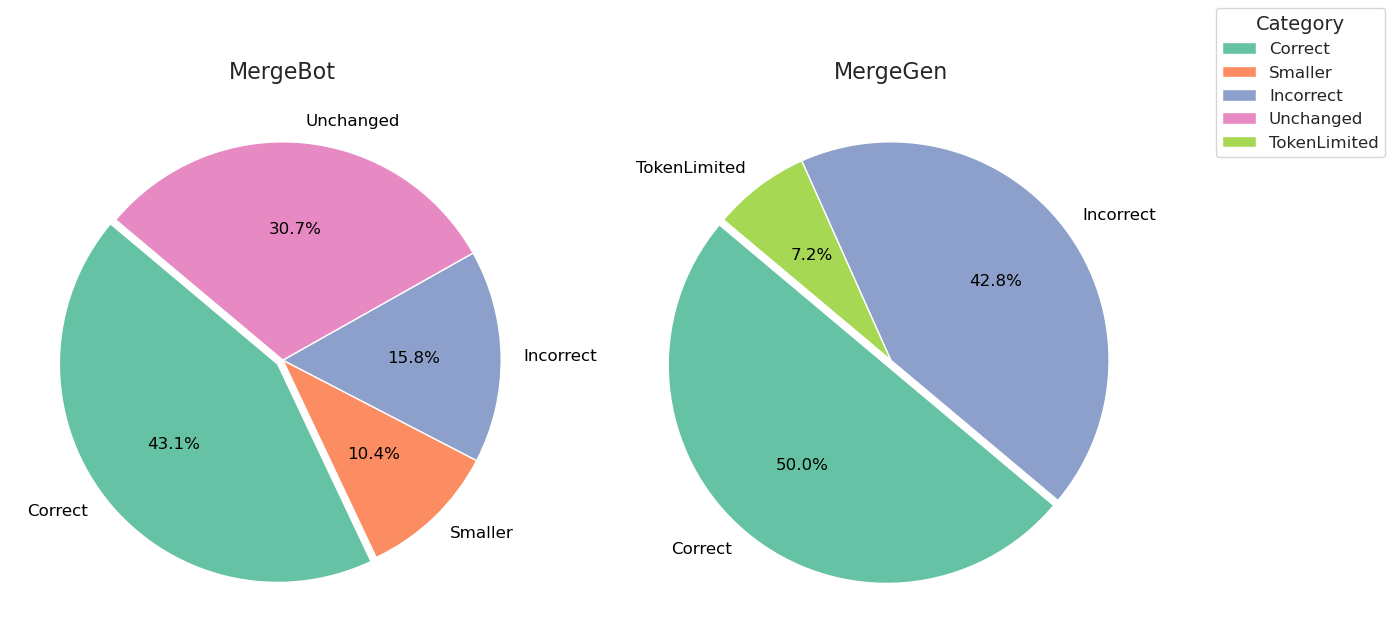

In [ ]:
# 定义类别
from matplotlib.patches import Patch


categories = ["Correct", "Smaller", "Incorrect", "Unchanged", "TokenLimited"]

# 使用 Seaborn 的配色方案
sns.set(style="whitegrid")
palette = sns.color_palette("Set2", len(categories))  # 选择 Set2 配色方案

# 创建一个颜色字典
color_dict = dict(zip(categories, palette))

# 设置图表大小
fig, axes = plt.subplots(1, 2, figsize=(14, 7))

# 设置标题
#fig.suptitle('Method Comparison: MergeBot vs MergeGen', fontsize=20)

# 遍历每种方法，绘制饼状图
for ax, method in zip(axes, aggregated.index):
    data = aggregated.loc[method]
    
    # 过滤出数量大于 0 的类别
    data = data[data > 0]
    
    # 更新类别列表以匹配过滤后的数据
    filtered_categories = data.index.tolist()
    
    # 计算每个类别的百分比
    percentages = data / data.sum() * 100
    
    # 创建 explode 列表，突出显示 "Correct" 类别
    explode = [0.03 if cat == "Correct" else 0 for cat in filtered_categories]
    
    # 绘制饼状图
    wedges, texts, autotexts = ax.pie(
        data,
        labels=filtered_categories,
        colors=[color_dict[cat] for cat in filtered_categories],
        autopct='%1.1f%%',
        startangle=140,
        textprops={'color': 'black', 'fontsize': 12},
        explode=explode,
        wedgeprops=dict(edgecolor='white')
    )
    
    # 设置标题
    ax.set_title(method, fontsize=16)

# 创建图例
legend_elements = [Patch(facecolor=color_dict[cat], label=cat) for cat in category_columns]

# 添加共用图例到整个图的右侧
fig.legend(handles=legend_elements, loc='upper right', title='Category', fontsize=12, title_fontsize=14)

# 调整布局以防止图例遮挡
plt.tight_layout(rect=[0, 0.03, 0.85, 0.95])

# 显示图表
plt.show()

### Line Level Effectivness

In [ ]:
line_level_data = [
    {"Project": "duckdb", "Method": "MergeBot", "Precision": 0.6805567119029778, "Recall": 0.8931400579097846},
    {"Project": "duckdb", "Method": "GitMerge", "Precision": 0.8932650489777669, "Recall": 0.8004297707282428},
    {"Project": "duckdb", "Method": "MergeGen", "Precision": 0.9494591400781747, "Recall": 0.7608398739824814},
    {"Project": "frameworks_av", "Method": "MergeBot", "Precision": 0.914188783095562, "Recall": 0.9054743124799286},
    {"Project": "frameworks_av", "Method": "GitMerge", "Precision": 0.9649843827059017, "Recall": 0.7816306229390063},
    {"Project": "frameworks_av", "Method": "MergeGen", "Precision": 0.9847069336691173, "Recall": 0.759542253796928},
    {"Project": "system_core", "Method": "MergeBot", "Precision": 0.8428702322990963, "Recall": 0.8242559471520433},
    {"Project": "system_core", "Method": "GitMerge", "Precision": 0.9137132699861749, "Recall": 0.7315260550265293},
    {"Project": "system_core", "Method": "MergeGen", "Precision": 0.9582872724592821, "Recall": 0.6853543694437612},
    {"Project": "flameshot", "Method": "MergeBot", "Precision": 0.9716752090639331, "Recall": 0.9780070594623947},
    {"Project": "flameshot", "Method": "GitMerge", "Precision": 0.8772509003601441, "Recall": 0.7936464838446918},
    {"Project": "flameshot", "Method": "MergeGen", "Precision": 0.9146807349463344, "Recall": 0.6825957100190062},
    {"Project": "tmux", "Method": "MergeBot", "Precision": 0.9571607789467682, "Recall": 0.8835969783907562},
    {"Project": "tmux", "Method": "GitMerge", "Precision": 0.9754900362023418, "Recall": 0.7872371226278525},
    {"Project": "tmux", "Method": "MergeGen", "Precision": 0.9927924598041028, "Recall": 0.777669570710394},
    {"Project": "redis", "Method": "MergeBot", "Precision": 0.9307018559246827, "Recall": 0.9825754875502826},
    {"Project": "redis", "Method": "GitMerge", "Precision": 0.9824545870408901, "Recall": 0.6780182290340648},
    {"Project": "redis", "Method": "MergeGen", "Precision": 0.9936141304347826, "Recall": 0.6702683436020164},
    {"Project": "frameworks_native", "Method": "MergeBot", "Precision": 0.9129485521918377, "Recall": 0.9356475867845044},
    {"Project": "frameworks_native", "Method": "GitMerge", "Precision": 0.9488903620923699, "Recall": 0.7514781804317662},
    {"Project": "frameworks_native", "Method": "MergeGen", "Precision": 0.9948231667476419, "Recall": 0.7422778354188282},
    {"Project": "rocksdb", "Method": "MergeBot", "Precision": 0.6975792215234888, "Recall": 0.8736974326766557},
    {"Project": "rocksdb", "Method": "GitMerge", "Precision": 0.9640799141418311, "Recall": 0.748401030518207},
    {"Project": "rocksdb", "Method": "MergeGen", "Precision": 0.9777642559109875, "Recall": 0.7208628667375896},
    {"Project": "grpc", "Method": "MergeBot", "Precision": 0.6369353739389058, "Recall": 0.8090749886857795},
    {"Project": "grpc", "Method": "GitMerge", "Precision": 0.9165184070069796, "Recall": 0.7906574054032782},
    {"Project": "grpc", "Method": "MergeGen", "Precision": 0.9869310387828907, "Recall": 0.7786348163160898},
    {"Project": "art", "Method": "MergeBot", "Precision": 0.6883281423217019, "Recall": 0.8134326495982432},
    {"Project": "art", "Method": "GitMerge", "Precision": 0.9616591963267792, "Recall": 0.7682786844337974},
    {"Project": "art", "Method": "MergeGen", "Precision": 0.9813909867219507, "Recall": 0.7441982332684534},
]

# 创建 DataFrame
df_line = pd.DataFrame(line_level_data)

# 查看 DataFrame
print("完整的数据表:")
print(df_line.head(30))


完整的数据表:
              Project    Method  Precision    Recall
0              duckdb  MergeBot   0.680557  0.893140
1              duckdb  GitMerge   0.893265  0.800430
2              duckdb  MergeGen   0.949459  0.760840
3       frameworks_av  MergeBot   0.914189  0.905474
4       frameworks_av  GitMerge   0.964984  0.781631
5       frameworks_av  MergeGen   0.984707  0.759542
6         system_core  MergeBot   0.842870  0.824256
7         system_core  GitMerge   0.913713  0.731526
8         system_core  MergeGen   0.958287  0.685354
9           flameshot  MergeBot   0.971675  0.978007
10          flameshot  GitMerge   0.877251  0.793646
11          flameshot  MergeGen   0.914681  0.682596
12               tmux  MergeBot   0.957161  0.883597
13               tmux  GitMerge   0.975490  0.787237
14               tmux  MergeGen   0.992792  0.777670
15              redis  MergeBot   0.930702  0.982575
16              redis  GitMerge   0.982455  0.678018
17              redis  MergeGen   0.99

In [ ]:
# 计算每种方法的平均 Precision 和 Recall
average_metrics = df_line.groupby("Method")[["Precision", "Recall"]].mean().reset_index()

print("\n每种方法的平均 Precision 和 Recall:\n")
print(average_metrics)


每种方法的平均 Precision 和 Recall:

     Method  Precision    Recall
0  GitMerge   0.939831  0.763130
1  MergeBot   0.823294  0.889890
2  MergeGen   0.973445  0.732224


### Abalation Study

In [ ]:
data_ablation = {
    'Project': [
        'flameshot', 'duckdb', 'rocksdb', 'grpc', 'art',
        'frameworks/av', 'frameworks/native', 'system/core', 'redis', 'tmux',
        'Total', 'ChangeRate'
    ],
    'Correct_MergeBot_minus': [12, 39, 113, 38, 36, 103, 129, 70, 16, 35, 591, '7.6%'],
    'Correct_MergeBot': [14, 47, 118, 42, 43, 103, 133, 78, 19, 39, 636, '7.6%'],
    'Smaller_MergeBot_minus': [3, 22, 10, 18, 10, 40, 18, 14, 2, 8, 145, '0.0%'],
    'Smaller_MergeBot': [3, 22, 10, 18, 10, 40, 18, 14, 2, 8, 145, '0.0%'],
    'Incorrect_MergeBot_minus': [2, 12, 75, 48, 14, 18, 8, 16, 7, 21, 221, '2.7%'],
    'Incorrect_MergeBot': [2, 14, 75, 48, 15, 18, 8, 18, 7, 22, 227, '2.7%'],
    'Unchanged_MergeBot_minus': [9, 70, 47, 48, 70, 103, 24, 50, 43, 29, 493, '-10.3%'],
    'Unchanged_MergeBot': [7, 60, 42, 44, 62, 103, 20, 40, 40, 24, 442, '-10.3%']
}

# Create the DataFrame
df_ablation = pd.DataFrame(data_ablation)
df_ablation

,Project,Correct_MergeBot_minus,Correct_MergeBot,Smaller_MergeBot_minus,Smaller_MergeBot,Incorrect_MergeBot_minus,Incorrect_MergeBot,Unchanged_MergeBot_minus,Unchanged_MergeBot
0,flameshot,12,14,3,3,2,2,9,7
1,duckdb,39,47,22,22,12,14,70,60
2,rocksdb,113,118,10,10,75,75,47,42
3,grpc,38,42,18,18,48,48,48,44
4,art,36,43,10,10,14,15,70,62
5,frameworks/av,103,103,40,40,18,18,103,103
6,frameworks/native,129,133,18,18,8,8,24,20
7,system/core,70,78,14,14,16,18,50,40
8,redis,16,19,2,2,7,7,43,40
9,tmux,35,39,8,8,21,22,29,24


### Efficiency

In [ ]:
import os
from pathlib import Path
import re
import sys

# Initialize lists to store extracted data

nodes = []
times = []

# Define the multiline regular expression pattern
pattern = r"Base:\s+(\d+)\s+nodes,.*?it takes\s+([\d.]+) ms to build"


log_file = './mergebot-logs/mergebot.log'
if not os.path.exists(log_file) or not Path(log_file).is_file():
    print(f'Error: The file "{log_file}" does not exist.', file=sys.stderr)
    exit(1)

# Open and read the entire log file content
with open(log_file, "r") as file:
    content = file.read()

# Find all matches in the entire content
matches = re.findall(pattern, content, re.DOTALL)

# Loop through all matches and store them in lists
for match in matches:
    nodes.append(int(match[0]))
    times.append(float(match[1]))

# Create a DataFrame
df_effi_mergebot = pd.DataFrame({"Nodes": nodes, "Time (ms)": times})

df_effi_mergebot.head(20)

,Nodes,Time (ms)
0,615,68966.634561
1,25,1358.214232
2,487,16142.561464
3,913,41648.256900
4,440,19882.356680
5,120,3679.720564
6,334,13378.456642
7,78,2524.374233
8,259,8488.063687
9,562,26540.821523


In [ ]:
data_mergegen = [155.6311/24] * 24 + [56.2393 / 36] * 36 + [1005.9254/30]*30 + [101.1682/32]*32 + [184.5018 / 37] * 37 + [69.4995 / 37] * 37 + [119.9240 / 26] * 26 + [103.2436 / 33] * 33 + [174.2819 / 27] * 27 + [20.1751 / 7] * 7

data_mergegen = [time_ms * 1000 for time_ms in data_mergegen]

data_mergegen

[6484.6291666666675,
 6484.6291666666675,
 6484.6291666666675,
 6484.6291666666675,
 6484.6291666666675,
 6484.6291666666675,
 6484.6291666666675,
 6484.6291666666675,
 6484.6291666666675,
 6484.6291666666675,
 6484.6291666666675,
 6484.6291666666675,
 6484.6291666666675,
 6484.6291666666675,
 6484.6291666666675,
 6484.6291666666675,
 6484.6291666666675,
 6484.6291666666675,
 6484.6291666666675,
 6484.6291666666675,
 6484.6291666666675,
 6484.6291666666675,
 6484.6291666666675,
 6484.6291666666675,
 1562.2027777777778,
 1562.2027777777778,
 1562.2027777777778,
 1562.2027777777778,
 1562.2027777777778,
 1562.2027777777778,
 1562.2027777777778,
 1562.2027777777778,
 1562.2027777777778,
 1562.2027777777778,
 1562.2027777777778,
 1562.2027777777778,
 1562.2027777777778,
 1562.2027777777778,
 1562.2027777777778,
 1562.2027777777778,
 1562.2027777777778,
 1562.2027777777778,
 1562.2027777777778,
 1562.2027777777778,
 1562.2027777777778,
 1562.2027777777778,
 1562.2027777777778,
 1562.2027777

/home/whalien/miniforge3/lib/python3.10/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/home/whalien/miniforge3/lib/python3.10/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/home/whalien/miniforge3/lib/python3.10/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):


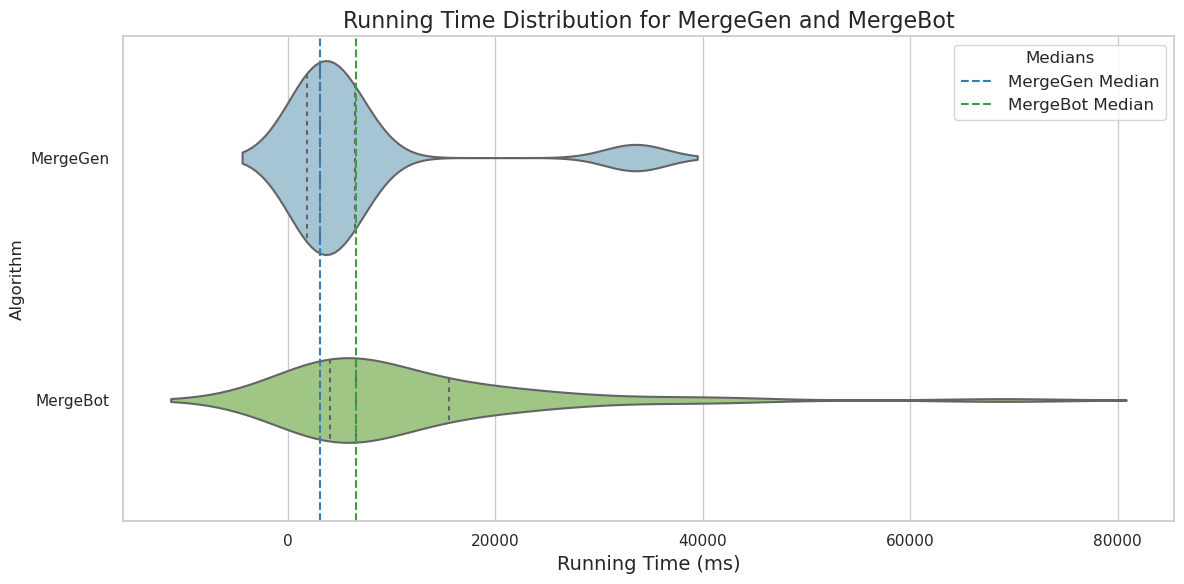

In [ ]:
df = pd.DataFrame({
    "Time (ms)": data_mergegen + df_effi_mergebot["Time (ms)"].tolist(),
    "Algorithm": ['MergeGen'] * len(data_mergegen) + ['MergeBot'] * len(df_effi_mergebot)
})

# Create a custom color palette for the two algorithms
palette = {"MergeGen": "#9DC7DD", "MergeBot": "#9ED17B"}

# Create the Violin plot with time on the x-axis and algorithm on the y-axis
plt.figure(figsize=(12, 6))
sns.violinplot(x='Time (ms)', y='Algorithm', data=df, inner="quart", palette=palette)

# Calculate medians
mergegen_median = df[df['Algorithm'] == 'MergeGen']['Time (ms)'].median()
mergebot_median = df[df['Algorithm'] == 'MergeBot']['Time (ms)'].median()

# Add median lines with custom colors
plt.axvline(mergegen_median, color='#367DB0', linestyle='--', label='MergeGen Median')
plt.axvline(mergebot_median, color='#3D9F3C', linestyle='--', label='MergeBot Median')

# Get the axis object for positioning text precisely
ax = plt.gca()

# Customize the plot
plt.title('Running Time Distribution for MergeGen and MergeBot', fontsize=16)
plt.xlabel('Running Time (ms)', fontsize=14)
plt.legend(title="Medians", fontsize=12)

# Display the plot
plt.tight_layout()
plt.show()

/home/whalien/miniforge3/lib/python3.10/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/home/whalien/miniforge3/lib/python3.10/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/home/whalien/miniforge3/lib/python3.10/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):


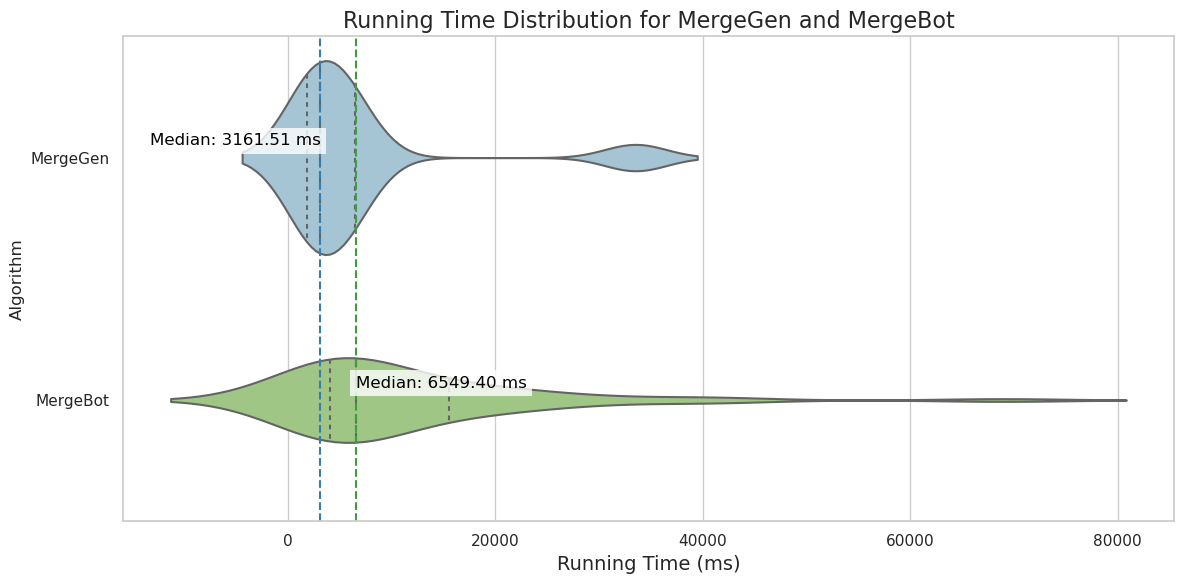

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Assuming data_mergegen and df_effi_mergebot are already defined
df = pd.DataFrame({
    "Time (ms)": data_mergegen + df_effi_mergebot["Time (ms)"].tolist(),
    "Algorithm": ['MergeGen'] * len(data_mergegen) + ['MergeBot'] * len(df_effi_mergebot)
})

# Create a custom color palette for the two algorithms
palette = {"MergeGen": "#9DC7DD", "MergeBot": "#9ED17B"}

# Create the Violin plot with time on the x-axis and algorithm on the y-axis
plt.figure(figsize=(12, 6))
sns.violinplot(x='Time (ms)', y='Algorithm', data=df, inner="quart", palette=palette)

# Calculate medians
mergegen_median = df[df['Algorithm'] == 'MergeGen']['Time (ms)'].median()
mergebot_median = df[df['Algorithm'] == 'MergeBot']['Time (ms)'].median()

# Add median lines with custom colors
plt.axvline(mergegen_median, color='#367DB0', linestyle='--')
plt.axvline(mergebot_median, color='#3D9F3C', linestyle='--')

# Get the axis object for positioning text precisely
ax = plt.gca()

# Annotate the median values on the plot
# Determine the y-positions for each algorithm
# In a horizontal violin plot, y=0 corresponds to the first category, y=1 to the second, etc.
# Adjust these if you have more categories or different ordering

# Get the unique algorithms in the order they appear on the plot
algorithms = df['Algorithm'].unique()
y_positions = range(len(algorithms))  # e.g., [0, 1]

# Create a mapping from algorithm to y-position
algo_to_y = {algo: y for algo, y in zip(algorithms, y_positions)}

# Annotate MergeGen median
ax.text(mergegen_median - 0.2, algo_to_y['MergeGen'] - 0.1, 
        f'Median: {mergegen_median:.2f} ms',
        color='#000000', 
        fontsize=12, 
        verticalalignment='top',
        horizontalalignment='right', 
        bbox=dict(facecolor='white', alpha=0.8, edgecolor='none'))

# Annotate MergeBot median
ax.text(mergebot_median, algo_to_y['MergeBot'] - 0.1, 
        f'Median: {mergebot_median:.2f} ms',
        color='#000000', 
        fontsize=12, 
        verticalalignment='top',
        horizontalalignment='left', 
        bbox=dict(facecolor='white', alpha=0.8, edgecolor='none'))

# Customize the plot
plt.title('Running Time Distribution for MergeGen and MergeBot', fontsize=16)
plt.xlabel('Running Time (ms)', fontsize=14)

# Optionally, remove the legend since annotations are added
# plt.legend(title="Medians", fontsize=12)

# Display the plot
plt.tight_layout()
plt.show()


In [2]:
import pandas as pd
import numpy as np

# 创建DataFrame
data = {
    'Project': ['flameshot', 'duckdb', 'rocksdb', 'grpc', 'art', 'frameworks/av', 
                'frameworks/native', 'system/core', 'redis', 'tmux'],
    'Precision': [0.737, 0.566, 0.581, 0.389, 0.642, 0.640, 0.781, 0.709, 0.679, 0.565],
    'Accuracy': [0.538, 0.329, 0.482, 0.276, 0.336, 0.399, 0.676, 0.519, 0.279, 0.419],
    'variation': [0.199, 0.237, 0.099, 0.113, 0.306, 0.241, 0.105, 0.190, 0.400, 0.146],
    'Total': [26, 143, 245, 152, 128, 264, 179, 160, 68, 93],
    'heuristic': [2, 10, 13, 4, 8, 11, 12, 10, 3, 5]
}

df = pd.DataFrame(data)

# 1. 计算correct列
df['correct'] = round(df['Total'] * df['Accuracy']).astype(int)

# 2. 计算attempt列
df['attempt'] = round(df['correct'] / df['Precision']).astype(int)

# 3. 计算structural列
df['structural'] = df['attempt'] - df['heuristic']

# 4. 计算semantic列
df['semantic'] = df['Total'] - df['structural']

# 5. 计算semantic_ratio列
df['semantic_ratio'] = df['semantic'] / df['Total']

# 显示结果（保留原始列+新计算列）
final_columns = ['Project', 'Precision', 'Accuracy', 'Total', 'heuristic', 
                'correct', 'attempt', 'structural', 'semantic', 'semantic_ratio']
print(df[final_columns].round(3))

print(df['semantic_ratio'].mean())

             Project  Precision  Accuracy  Total  heuristic  correct  attempt  \
0          flameshot      0.737     0.538     26          2       14       19   
1             duckdb      0.566     0.329    143         10       47       83   
2            rocksdb      0.581     0.482    245         13      118      203   
3               grpc      0.389     0.276    152          4       42      108   
4                art      0.642     0.336    128          8       43       67   
5      frameworks/av      0.640     0.399    264         11      105      164   
6  frameworks/native      0.781     0.676    179         12      121      155   
7        system/core      0.709     0.519    160         10       83      117   
8              redis      0.679     0.279     68          3       19       28   
9               tmux      0.565     0.419     93          5       39       69   

   structural  semantic  semantic_ratio  
0          17         9           0.346  
1          73        70 

In [ ]:
df['variation'] = df['Precision'] - df['Accuracy']


             Project  variation
0          flameshot      0.199
1             duckdb      0.237
2            rocksdb      0.099
3               grpc      0.113
4                art      0.306
5      frameworks/av      0.241
6  frameworks/native      0.105
7        system/core      0.190
8              redis      0.400
9               tmux      0.146


In [5]:
print(df[['Project', 'variation']].sort_values(by='variation', ascending=False))

             Project  variation
8              redis      0.400
4                art      0.306
5      frameworks/av      0.241
1             duckdb      0.237
0          flameshot      0.199
7        system/core      0.190
9               tmux      0.146
3               grpc      0.113
6  frameworks/native      0.105
2            rocksdb      0.099
